In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
from sklearn.preprocessing import StandardScaler

c:\Users\Usuario\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
df = pd.read_csv("incident_event_log.csv")
df

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,INC0120835,Closed,False,1,0,4,True,Caller 116,Opened by 12,16/2/2017 09:09,...,True,Do Not Notify,?,?,?,?,code 9,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,INC0121064,Active,True,0,0,0,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141709,INC0121064,Active,True,1,0,1,True,Caller 116,Opened by 12,16/2/2017 14:17,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,INC0121064,Resolved,True,1,0,2,True,Caller 116,Opened by 12,16/2/2017 14:17,...,True,Do Not Notify,?,?,?,?,code 6,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [3]:
df.replace("?", np.nan, inplace=True)
df.drop_duplicates().shape
columnas_a_eliminar = ['caused_by', 'vendor', 'cmdb_ci','rfc', 'problem_id', 'sys_created_by','sys_created_at','u_symptom']
df = df.drop(columns=columnas_a_eliminar, errors='ignore')
df.dtypes

number                     object
incident_state             object
active                       bool
reassignment_count          int64
reopen_count                int64
sys_mod_count               int64
made_sla                     bool
caller_id                  object
opened_by                  object
opened_at                  object
sys_updated_by             object
sys_updated_at             object
contact_type               object
location                   object
category                   object
subcategory                object
impact                     object
urgency                    object
priority                   object
assignment_group           object
assigned_to                object
knowledge                    bool
u_priority_confirmation      bool
notify                     object
closed_code                object
resolved_by                object
resolved_at                object
closed_at                  object
dtype: object

## Ahora se van a quitar las columnas que no se pueden generalizar en un modelo de predicción

In [4]:
#initial_state no se va a usar porqué se estaría cayendo el data leakage
df=df[df["incident_state"].isin(["New", "Active",'Resolved','Closed'])]
df = df.drop(columns=['incident_state'], errors='ignore')
# df=df[df['active'] == True]
df = df.drop(columns=['caller_id','opened_by','u_symptom','closed_code'], errors='ignore')
df

,number,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,...,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at
0,INC0000045,True,0,0,0,True,29/2/2016 01:16,Updated by 21,29/2/2016 01:23,Phone,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,True,0,0,2,True,29/2/2016 01:16,Updated by 642,29/2/2016 08:53,Phone,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,True,0,0,3,True,29/2/2016 01:16,Updated by 804,29/2/2016 11:29,Phone,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,False,0,0,4,True,29/2/2016 01:16,Updated by 908,5/3/2016 12:00,Phone,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,True,0,0,0,True,29/2/2016 04:40,Updated by 746,29/2/2016 04:57,Phone,...,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,INC0120835,False,1,0,4,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,Email,...,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,INC0121064,True,0,0,0,True,16/2/2017 14:17,Updated by 908,16/2/2017 14:17,Email,...,2 - Medium,3 - Moderate,Group 70,Resolver 10,False,False,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141709,INC0121064,True,1,0,1,True,16/2/2017 14:17,Updated by 60,16/2/2017 15:20,Email,...,2 - Medium,3 - Moderate,Group 31,NaN,False,False,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,INC0121064,True,1,0,2,True,16/2/2017 14:17,Updated by 27,16/2/2017 16:38,Email,...,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [5]:
df = df.drop(columns=['number'], errors='ignore')
df

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,location,...,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at
0,True,0,0,0,True,29/2/2016 01:16,Updated by 21,29/2/2016 01:23,Phone,Location 143,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,True,0,0,2,True,29/2/2016 01:16,Updated by 642,29/2/2016 08:53,Phone,Location 143,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,True,0,0,3,True,29/2/2016 01:16,Updated by 804,29/2/2016 11:29,Phone,Location 143,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,False,0,0,4,True,29/2/2016 01:16,Updated by 908,5/3/2016 12:00,Phone,Location 143,...,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,True,0,0,0,True,29/2/2016 04:40,Updated by 746,29/2/2016 04:57,Phone,Location 165,...,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141707,False,1,0,4,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,Email,Location 204,...,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,True,0,0,0,True,16/2/2017 14:17,Updated by 908,16/2/2017 14:17,Email,Location 204,...,2 - Medium,3 - Moderate,Group 70,Resolver 10,False,False,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141709,True,1,0,1,True,16/2/2017 14:17,Updated by 60,16/2/2017 15:20,Email,Location 204,...,2 - Medium,3 - Moderate,Group 31,NaN,False,False,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,True,1,0,2,True,16/2/2017 14:17,Updated by 27,16/2/2017 16:38,Email,Location 204,...,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [6]:
df=df.dropna()
df

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,location,...,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at
4,True,0,0,0,True,29/2/2016 04:40,Updated by 746,29/2/2016 04:57,Phone,Location 165,...,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
5,True,1,0,1,True,29/2/2016 04:40,Updated by 21,29/2/2016 05:30,Phone,Location 165,...,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
6,True,1,0,2,True,29/2/2016 04:40,Updated by 21,29/2/2016 05:33,Phone,Location 165,...,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
7,True,1,0,3,True,29/2/2016 04:40,Updated by 804,29/2/2016 11:31,Phone,Location 165,...,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
8,True,1,0,4,True,29/2/2016 04:40,Updated by 703,29/2/2016 11:32,Phone,Location 165,...,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,True,1,0,3,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,Email,Location 204,...,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141707,False,1,0,4,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,Email,Location 204,...,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,True,0,0,0,True,16/2/2017 14:17,Updated by 908,16/2/2017 14:17,Email,Location 204,...,2 - Medium,3 - Moderate,Group 70,Resolver 10,False,False,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,True,1,0,2,True,16/2/2017 14:17,Updated by 27,16/2/2017 16:38,Email,Location 204,...,2 - Medium,3 - Moderate,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [7]:
df["impact"] = df["impact"].replace({"1 - High": 1, "2 - Medium": 2, "3 - Low": 3})
df["urgency"] = df["urgency"].replace({"1 - High": 1, "2 - Medium": 2, "3 - Low": 3})
df["priority"] = df["priority"].replace({"1 - Critical": 1, "2 - High": 2, "3 - Moderate": 3,'4 - Low':4})
# df["incident_state"] = df["incident_state"].replace({"New": 1, "Active": 2, "Resolved": 3,'Closed':4})
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\1273835431.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["impact"] = df["impact"].replace({"1 - High": 1, "2 - Medium": 2, "3 - Low": 3})
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\1273835431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["impact"] = df["impact"].replace({"1 - High": 1, "2 - Medium": 2, "3 - Low": 3})
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\1273835431.py:2: FutureWarning: Downcasting behavior in `replace` is depre

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,location,...,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at
4,True,0,0,0,True,29/2/2016 04:40,Updated by 746,29/2/2016 04:57,Phone,Location 165,...,2,3,Group 70,Resolver 89,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
5,True,1,0,1,True,29/2/2016 04:40,Updated by 21,29/2/2016 05:30,Phone,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
6,True,1,0,2,True,29/2/2016 04:40,Updated by 21,29/2/2016 05:33,Phone,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
7,True,1,0,3,True,29/2/2016 04:40,Updated by 804,29/2/2016 11:31,Phone,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
8,True,1,0,4,True,29/2/2016 04:40,Updated by 703,29/2/2016 11:32,Phone,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,True,1,0,3,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,Email,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141707,False,1,0,4,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,Email,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,True,0,0,0,True,16/2/2017 14:17,Updated by 908,16/2/2017 14:17,Email,Location 204,...,2,3,Group 70,Resolver 10,False,False,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,True,1,0,2,True,16/2/2017 14:17,Updated by 27,16/2/2017 16:38,Email,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [8]:
df["contact_type"] = df["contact_type"].replace({"Phone": 1, "Email": 2, "Self service": 3,'Direct opening':4,'IVR':5})
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\1704511547.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["contact_type"] = df["contact_type"].replace({"Phone": 1, "Email": 2, "Self service": 3,'Direct opening':4,'IVR':5})
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\1704511547.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["contact_type"] = df["contact_type"].replace({"Phone": 1, "Email": 2, "Self service": 3,'Direct opening':4,'IVR':5})


,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,location,...,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at
4,True,0,0,0,True,29/2/2016 04:40,Updated by 746,29/2/2016 04:57,1,Location 165,...,2,3,Group 70,Resolver 89,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
5,True,1,0,1,True,29/2/2016 04:40,Updated by 21,29/2/2016 05:30,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
6,True,1,0,2,True,29/2/2016 04:40,Updated by 21,29/2/2016 05:33,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
7,True,1,0,3,True,29/2/2016 04:40,Updated by 804,29/2/2016 11:31,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
8,True,1,0,4,True,29/2/2016 04:40,Updated by 703,29/2/2016 11:32,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,True,1,0,3,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,2,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141707,False,1,0,4,True,16/2/2017 09:09,Updated by 27,16/2/2017 09:53,2,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 09:53,16/2/2017 09:53
141708,True,0,0,0,True,16/2/2017 14:17,Updated by 908,16/2/2017 14:17,2,Location 204,...,2,3,Group 70,Resolver 10,False,False,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38
141710,True,1,0,2,True,16/2/2017 14:17,Updated by 27,16/2/2017 16:38,2,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,16/2/2017 16:38,16/2/2017 16:38


In [9]:
df.dtypes

active                       bool
reassignment_count          int64
reopen_count                int64
sys_mod_count               int64
made_sla                     bool
opened_at                  object
sys_updated_by             object
sys_updated_at             object
contact_type                int64
location                   object
category                   object
subcategory                object
impact                      int64
urgency                     int64
priority                    int64
assignment_group           object
assigned_to                object
knowledge                    bool
u_priority_confirmation      bool
notify                     object
resolved_by                object
resolved_at                object
closed_at                  object
dtype: object

In [10]:
df['opened_at'] = pd.to_datetime(df['opened_at'], format="%d/%m/%Y %H:%M")
df['sys_updated_at'] = pd.to_datetime(df['sys_updated_at'], format="%d/%m/%Y %H:%M")
df['resolved_at'] = pd.to_datetime(df['resolved_at'], format="%d/%m/%Y %H:%M")
df['closed_at'] = pd.to_datetime(df['closed_at'], format="%d/%m/%Y %H:%M")
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\2941709518.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['opened_at'] = pd.to_datetime(df['opened_at'], format="%d/%m/%Y %H:%M")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\2941709518.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sys_updated_at'] = pd.to_datetime(df['sys_updated_at'], format="%d/%m/%Y %H:%M")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\2941709518.py:3: SettingWithCopyWarning: 
A value is trying to be set 

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,location,...,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at
4,True,0,0,0,True,2016-02-29 04:40:00,Updated by 746,2016-02-29 04:57:00,1,Location 165,...,2,3,Group 70,Resolver 89,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
5,True,1,0,1,True,2016-02-29 04:40:00,Updated by 21,2016-02-29 05:30:00,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
6,True,1,0,2,True,2016-02-29 04:40:00,Updated by 21,2016-02-29 05:33:00,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
7,True,1,0,3,True,2016-02-29 04:40:00,Updated by 804,2016-02-29 11:31:00,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
8,True,1,0,4,True,2016-02-29 04:40:00,Updated by 703,2016-02-29 11:32:00,1,Location 165,...,2,3,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,True,1,0,3,True,2017-02-16 09:09:00,Updated by 27,2017-02-16 09:53:00,2,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,2017-02-16 09:53:00,2017-02-16 09:53:00
141707,False,1,0,4,True,2017-02-16 09:09:00,Updated by 27,2017-02-16 09:53:00,2,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,2017-02-16 09:53:00,2017-02-16 09:53:00
141708,True,0,0,0,True,2017-02-16 14:17:00,Updated by 908,2017-02-16 14:17:00,2,Location 204,...,2,3,Group 70,Resolver 10,False,False,Do Not Notify,Resolved by 9,2017-02-16 16:38:00,2017-02-16 16:38:00
141710,True,1,0,2,True,2017-02-16 14:17:00,Updated by 27,2017-02-16 16:38:00,2,Location 204,...,2,3,Group 31,Resolver 10,False,True,Do Not Notify,Resolved by 9,2017-02-16 16:38:00,2017-02-16 16:38:00


In [11]:
df['time_diff'] = df['resolved_at'] - df['opened_at']
df['resolved_time'] = df['time_diff'] / pd.Timedelta(hours=1)
df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\150156571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_diff'] = df['resolved_at'] - df['opened_at']
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\150156571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['resolved_time'] = df['time_diff'] / pd.Timedelta(hours=1)


,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,location,...,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at,time_diff,resolved_time
4,True,0,0,0,True,2016-02-29 04:40:00,Updated by 746,2016-02-29 04:57:00,1,Location 165,...,Group 70,Resolver 89,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
5,True,1,0,1,True,2016-02-29 04:40:00,Updated by 21,2016-02-29 05:30:00,1,Location 165,...,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
6,True,1,0,2,True,2016-02-29 04:40:00,Updated by 21,2016-02-29 05:33:00,1,Location 165,...,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
7,True,1,0,3,True,2016-02-29 04:40:00,Updated by 804,2016-02-29 11:31:00,1,Location 165,...,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
8,True,1,0,4,True,2016-02-29 04:40:00,Updated by 703,2016-02-29 11:32:00,1,Location 165,...,Group 24,Resolver 31,True,False,Do Not Notify,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2


In [12]:
df["made_sla"] = df["made_sla"].replace({True: 1, False: 0})
df["knowledge"] = df["knowledge"].replace({True: 1, False: 0})
df["active"] = df["active"].replace({True: 1, False: 0})

df["u_priority_confirmation"] = df["u_priority_confirmation"].replace({True: 1, False: 0})
df["notify"] = df["notify"].replace({'Do Not Notify': 1, 'Send Email': 0})

df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\152482491.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["made_sla"] = df["made_sla"].replace({True: 1, False: 0})
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\152482491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["made_sla"] = df["made_sla"].replace({True: 1, False: 0})
C:\Users\Usuario\AppData\Local\Temp\ipykernel_29032\152482491.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,opened_at,sys_updated_by,sys_updated_at,contact_type,location,...,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_at,closed_at,time_diff,resolved_time
4,1,0,0,0,1,2016-02-29 04:40:00,Updated by 746,2016-02-29 04:57:00,1,Location 165,...,Group 70,Resolver 89,1,0,1,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
5,1,1,0,1,1,2016-02-29 04:40:00,Updated by 21,2016-02-29 05:30:00,1,Location 165,...,Group 24,Resolver 31,1,0,1,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
6,1,1,0,2,1,2016-02-29 04:40:00,Updated by 21,2016-02-29 05:33:00,1,Location 165,...,Group 24,Resolver 31,1,0,1,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
7,1,1,0,3,1,2016-02-29 04:40:00,Updated by 804,2016-02-29 11:31:00,1,Location 165,...,Group 24,Resolver 31,1,0,1,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2
8,1,1,0,4,1,2016-02-29 04:40:00,Updated by 703,2016-02-29 11:32:00,1,Location 165,...,Group 24,Resolver 31,1,0,1,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00,1 days 05:12:00,29.2


In [13]:
df = df.drop(columns=['opened_at','sys_updated_at','resolved_at','closed_at','time_diff'], errors='ignore')
df.head()

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,location,category,subcategory,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_time
4,1,0,0,0,1,Updated by 746,1,Location 165,Category 40,Subcategory 215,2,2,3,Group 70,Resolver 89,1,0,1,Resolved by 81,29.2
5,1,1,0,1,1,Updated by 21,1,Location 165,Category 40,Subcategory 215,2,2,3,Group 24,Resolver 31,1,0,1,Resolved by 81,29.2
6,1,1,0,2,1,Updated by 21,1,Location 165,Category 40,Subcategory 215,2,2,3,Group 24,Resolver 31,1,0,1,Resolved by 81,29.2
7,1,1,0,3,1,Updated by 804,1,Location 165,Category 40,Subcategory 215,2,2,3,Group 24,Resolver 31,1,0,1,Resolved by 81,29.2
8,1,1,0,4,1,Updated by 703,1,Location 165,Category 40,Subcategory 215,2,2,3,Group 24,Resolver 31,1,0,1,Resolved by 81,29.2


In [14]:
df['sys_updated_by']=df["sys_updated_by"].str.extract(r'(\d+)').astype(int)
df['category']=df["category"].str.extract(r'(\d+)').astype(int)
df['assignment_group']=df["assignment_group"].str.extract(r'(\d+)').astype(int)
df['assigned_to']=df["assigned_to"].str.extract(r'(\d+)').astype(int)
df['resolved_by']=df["resolved_by"].str.extract(r'(\d+)').astype(int)
df['location']=df["location"].str.extract(r'(\d+)').astype(int)
df['subcategory']=df["subcategory"].str.extract(r'(\d+)').astype(int)
df.head()

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,location,category,subcategory,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_time
4,1,0,0,0,1,746,1,165,40,215,2,2,3,70,89,1,0,1,81,29.2
5,1,1,0,1,1,21,1,165,40,215,2,2,3,24,31,1,0,1,81,29.2
6,1,1,0,2,1,21,1,165,40,215,2,2,3,24,31,1,0,1,81,29.2
7,1,1,0,3,1,804,1,165,40,215,2,2,3,24,31,1,0,1,81,29.2
8,1,1,0,4,1,703,1,165,40,215,2,2,3,24,31,1,0,1,81,29.2


In [15]:
df['made_sla'].describe()

count    90169.000000
mean         0.915658
std          0.277901
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: made_sla, dtype: float64

In [16]:
df

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,location,category,subcategory,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,resolved_by,resolved_time
4,1,0,0,0,1,746,1,165,40,215,2,2,3,70,89,1,0,1,81,29.200000
5,1,1,0,1,1,21,1,165,40,215,2,2,3,24,31,1,0,1,81,29.200000
6,1,1,0,2,1,21,1,165,40,215,2,2,3,24,31,1,0,1,81,29.200000
7,1,1,0,3,1,804,1,165,40,215,2,2,3,24,31,1,0,1,81,29.200000
8,1,1,0,4,1,703,1,165,40,215,2,2,3,24,31,1,0,1,81,29.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,1,1,0,3,1,27,2,204,42,223,2,2,3,31,10,0,1,1,9,0.733333
141707,0,1,0,4,1,27,2,204,42,223,2,2,3,31,10,0,1,1,9,0.733333
141708,1,0,0,0,1,908,2,204,42,223,2,2,3,70,10,0,0,1,9,2.350000
141710,1,1,0,2,1,27,2,204,42,223,2,2,3,31,10,0,1,1,9,2.350000


# Con base en estos datos se va a buscar hacer un modelo de predicción
#### $i$) mediante el mejor modelo de regresión 
#### $ii$) mediante redes neuronales cambiando # de capas, neuronas, variables de entrada y funciones de activación

In [17]:
# Variables
X=df.drop(columns='resolved_time', errors='ignore')
y = df[["resolved_time"]].copy()

## Regresión por OLS

Primera Iteración

In [18]:
#Ajustar modelo de regresión lineal por medio de  mínimos cuadrados ordinarios
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:          resolved_time   R-squared (uncentered):                   0.518
Model:                            OLS   Adj. R-squared (uncentered):              0.518
Method:                 Least Squares   F-statistic:                              5095.
Date:                Sat, 13 Sep 2025   Prob (F-statistic):                        0.00
Time:                        23:03:55   Log-Likelihood:                     -6.8211e+05
No. Observations:               90169   AIC:                                  1.364e+06
Df Residuals:                   90150   BIC:                                  1.364e+06
Df Model:                          19                                                  
Covariance Type:            nonrobust                                                  
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
active                     93.5208      5.856     15.971      0.000      82.044     104.998
reassignment_count        -83.8161      1.156    -72.490      0.000     -86.082     -81.550
reopen_count             -253.7255      7.310    -34.707      0.000    -268.054    -239.397
sys_mod_count              62.5204      0.259    241.840      0.000      62.014      63.027
made_sla                   33.2211      7.164      4.637      0.000      19.180      47.262
sys_updated_by             -0.0769      0.006    -13.192      0.000      -0.088      -0.065
contact_type               24.9239      8.415      2.962      0.003       8.430      41.418
location                    0.0114      0.028      0.406      0.685      -0.043       0.066
category                    0.9350      0.114      8.222      0.000       0.712       1.158
subcategory                -0.0141      0.023     -0.613      0.540      -0.059       0.031
impact                    -11.6996     14.840     -0.788      0.430     -40.786      17.387
urgency                   -12.5244     15.060     -0.832      0.406     -42.041      16.992
priority                   77.7513     14.650      5.307      0.000      49.038     106.464
assignment_group           -2.0380      0.075    -27.175      0.000      -2.185      -1.891
assigned_to                 0.4690      0.052      8.976      0.000       0.367       0.571
knowledge                  -0.9058      4.600     -0.197      0.844      -9.922       8.111
u_priority_confirmation  -183.1761      3.957    -46.293      0.000    -190.932    -175.421
notify                    -98.7840     18.583     -5.316      0.000    -135.207     -62.361
resolved_by                -0.6338      0.057    -11.084      0.000      -0.746      -0.522
==============================================================================
Omnibus:                   105110.960   Durbin-Watson:                   0.583
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         13704031.766
Skew:                           6.149   Prob(JB):                         0.00
Kurtosis:                      62.130   Cond. No.                     9.72e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 9.72e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
insignificant= model.pvalues[model.pvalues > 0.05].index
print("Variables no significativas:", insignificant)

Variables no significativas: Index(['location', 'subcategory', 'impact', 'urgency', 'knowledge'], dtype='object')


Segunda Iteración

In [20]:
# Variables
X=df.drop(columns=['resolved_time','location', 'subcategory', 'impact', 'urgency', 'knowledge'], errors='ignore')
y = df[["resolved_time"]].copy()
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:          resolved_time   R-squared (uncentered):                   0.518
Model:                            OLS   Adj. R-squared (uncentered):              0.518
Method:                 Least Squares   F-statistic:                              6915.
Date:                Sat, 13 Sep 2025   Prob (F-statistic):                        0.00
Time:                        23:03:56   Log-Likelihood:                     -6.8211e+05
No. Observations:               90169   AIC:                                  1.364e+06
Df Residuals:                   90155   BIC:                                  1.364e+06
Df Model:                          14                                                  
Covariance Type:            nonrobust                                                  
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
active                     93.3777      5.853     15.955      0.000      81.907     104.849
reassignment_count        -83.8370      1.155    -72.589      0.000     -86.101     -81.573
reopen_count             -253.4842      7.305    -34.698      0.000    -267.803    -239.166
sys_mod_count              62.5186      0.258    242.567      0.000      62.013      63.024
made_sla                   33.3463      7.140      4.670      0.000      19.352      47.340
sys_updated_by             -0.0770      0.006    -13.235      0.000      -0.088      -0.066
contact_type               24.8042      8.409      2.950      0.003       8.323      41.286
category                    0.9302      0.114      8.186      0.000       0.707       1.153
priority                   62.9998      4.416     14.265      0.000      54.344      71.656
assignment_group           -2.0355      0.075    -27.269      0.000      -2.182      -1.889
assigned_to                 0.4716      0.052      9.057      0.000       0.370       0.574
u_priority_confirmation  -183.0704      3.833    -47.765      0.000    -190.582    -175.558
notify                   -103.9740     17.523     -5.934      0.000    -138.319     -69.629
resolved_by                -0.6366      0.057    -11.164      0.000      -0.748      -0.525
==============================================================================
Omnibus:                   105096.704   Durbin-Watson:                   0.583
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         13695299.470
Skew:                           6.148   Prob(JB):                         0.00
Kurtosis:                      62.111   Cond. No.                     7.75e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 7.75e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [21]:
insignificant= model.pvalues[model.pvalues > 0.05].index
print("Variables no significativas:", insignificant)

Variables no significativas: Index([], dtype='object')


Se usa la distancia de Cook con el objetivo eliminar outliers y evitar Pitfalls que no se hayan encontrado antes

In [22]:
cooksd = model.get_influence().cooks_distance[0]
n = X.shape[0]
critical_d = 4/n
out_d = cooksd > critical_d
print(X.index[out_d], "\n", cooksd[out_d])
#eliminar outliers
x_out = X.drop(X.index[out_d])
y_out = y.drop(y.index[out_d])

Index([   132,    349,    543,    545,    546,    842,    843,    844,    845,
          846,
       ...
       141382, 141383, 141384, 141385, 141386, 141387, 141388, 141622, 141623,
       141629],
      dtype='int64', length=2834) 
 [4.51676248e-05 5.39916356e-05 4.48463247e-05 ... 6.09732860e-05
 4.92161548e-05 5.90797490e-05]


In [23]:
model = sm.OLS(y_out, x_out).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:          resolved_time   R-squared (uncentered):                   0.725
Model:                            OLS   Adj. R-squared (uncentered):              0.725
Method:                 Least Squares   F-statistic:                          1.644e+04
Date:                Sat, 13 Sep 2025   Prob (F-statistic):                        0.00
Time:                        23:03:56   Log-Likelihood:                     -5.8626e+05
No. Observations:               87335   AIC:                                  1.173e+06
Df Residuals:                   87321   BIC:                                  1.173e+06
Df Model:                          14                                                  
Covariance Type:            nonrobust                                                  
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
active                     86.7764      2.520     34.432      0.000      81.837      91.716
reassignment_count        -72.5103      0.565   -128.434      0.000     -73.617     -71.404
reopen_count             -194.6515      4.585    -42.456      0.000    -203.638    -185.665
sys_mod_count              56.6962      0.153    369.645      0.000      56.396      56.997
made_sla                    1.5004      3.124      0.480      0.631      -4.622       7.623
sys_updated_by             -0.0430      0.003    -17.014      0.000      -0.048      -0.038
contact_type               14.7677      4.058      3.639      0.000       6.813      22.722
category                    0.5133      0.049     10.454      0.000       0.417       0.610
priority                   25.9931      1.943     13.379      0.000      22.185      29.801
assignment_group           -0.2871      0.033     -8.785      0.000      -0.351      -0.223
assigned_to                 0.2307      0.024      9.780      0.000       0.184       0.277
u_priority_confirmation  -121.9051      1.675    -72.773      0.000    -125.188    -118.622
notify                   -107.9927      7.848    -13.761      0.000    -123.374     -92.611
resolved_by                -0.2492      0.026     -9.636      0.000      -0.300      -0.199
==============================================================================
Omnibus:                    43901.820   Durbin-Watson:                   0.682
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           511325.779
Skew:                           2.149   Prob(JB):                         0.00
Kurtosis:                      14.048   Cond. No.                     8.09e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 8.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
insignificant_without_outliers= model.pvalues[model.pvalues > 0.05].index
print("Variables no significativas:", insignificant_without_outliers)

Variables no significativas: Index(['made_sla'], dtype='object')


In [88]:
x_out=x_out.drop(columns=['made_sla'], errors='ignore')
model = sm.OLS(y_out, x_out).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:          resolved_time   R-squared (uncentered):                   0.725
Model:                            OLS   Adj. R-squared (uncentered):              0.725
Method:                 Least Squares   F-statistic:                          1.770e+04
Date:                Sun, 14 Sep 2025   Prob (F-statistic):                        0.00
Time:                        01:42:44   Log-Likelihood:                     -5.8626e+05
No. Observations:               87335   AIC:                                  1.173e+06
Df Residuals:                   87322   BIC:                                  1.173e+06
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
active                     87.3659      2.201     39.688      0.000      83.051      91.680
reassignment_count        -72.5064      0.565   -128.441      0.000     -73.613     -71.400
reopen_count             -194.6124      4.584    -42.454      0.000    -203.597    -185.628
sys_mod_count              56.6763      0.148    383.882      0.000      56.387      56.966
sys_updated_by             -0.0429      0.003    -17.011      0.000      -0.048      -0.038
contact_type               14.7704      4.058      3.640      0.000       6.816      22.725
category                    0.5128      0.049     10.446      0.000       0.417       0.609
priority                   26.0830      1.934     13.488      0.000      22.293      29.873
assignment_group           -0.2867      0.033     -8.775      0.000      -0.351      -0.223
assigned_to                 0.2307      0.024      9.778      0.000       0.184       0.277
u_priority_confirmation  -121.7733      1.653    -73.690      0.000    -125.012    -118.534
notify                   -107.3165      7.721    -13.900      0.000    -122.449     -92.184
resolved_by                -0.2494      0.026     -9.645      0.000      -0.300      -0.199
==============================================================================
Omnibus:                    43909.358   Durbin-Watson:                   0.682
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           511446.135
Skew:                           2.149   Prob(JB):                         0.00
Kurtosis:                      14.049   Cond. No.                     7.98e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 7.98e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [89]:
insignificant_without_outliers= model.pvalues[model.pvalues > 0.05].index
print("Variables no significativas:", insignificant_without_outliers)

Variables no significativas: Index([], dtype='object')


## Red Neuronal

In [25]:
x_out

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,category,priority,assignment_group,assigned_to,u_priority_confirmation,notify,resolved_by
4,1,0,0,0,1,746,1,40,3,70,89,0,1,81
5,1,1,0,1,1,21,1,40,3,24,31,0,1,81
6,1,1,0,2,1,21,1,40,3,24,31,0,1,81
7,1,1,0,3,1,804,1,40,3,24,31,0,1,81
8,1,1,0,4,1,703,1,40,3,24,31,0,1,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,1,1,0,3,1,27,2,42,3,31,10,1,1,9
141707,0,1,0,4,1,27,2,42,3,31,10,1,1,9
141708,1,0,0,0,1,908,2,42,3,70,10,0,1,9
141710,1,1,0,2,1,27,2,42,3,31,10,1,1,9


In [26]:
y_out

,resolved_time
4,29.200000
5,29.200000
6,29.200000
7,29.200000
8,29.200000
...,...
141706,0.733333
141707,0.733333
141708,2.350000
141710,2.350000


In [27]:
df_final = pd.concat([x_out, y_out], axis=1)
df_final

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,category,priority,assignment_group,assigned_to,u_priority_confirmation,notify,resolved_by,resolved_time
4,1,0,0,0,1,746,1,40,3,70,89,0,1,81,29.200000
5,1,1,0,1,1,21,1,40,3,24,31,0,1,81,29.200000
6,1,1,0,2,1,21,1,40,3,24,31,0,1,81,29.200000
7,1,1,0,3,1,804,1,40,3,24,31,0,1,81,29.200000
8,1,1,0,4,1,703,1,40,3,24,31,0,1,81,29.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,1,1,0,3,1,27,2,42,3,31,10,1,1,9,0.733333
141707,0,1,0,4,1,27,2,42,3,31,10,1,1,9,0.733333
141708,1,0,0,0,1,908,2,42,3,70,10,0,1,9,2.350000
141710,1,1,0,2,1,27,2,42,3,31,10,1,1,9,2.350000


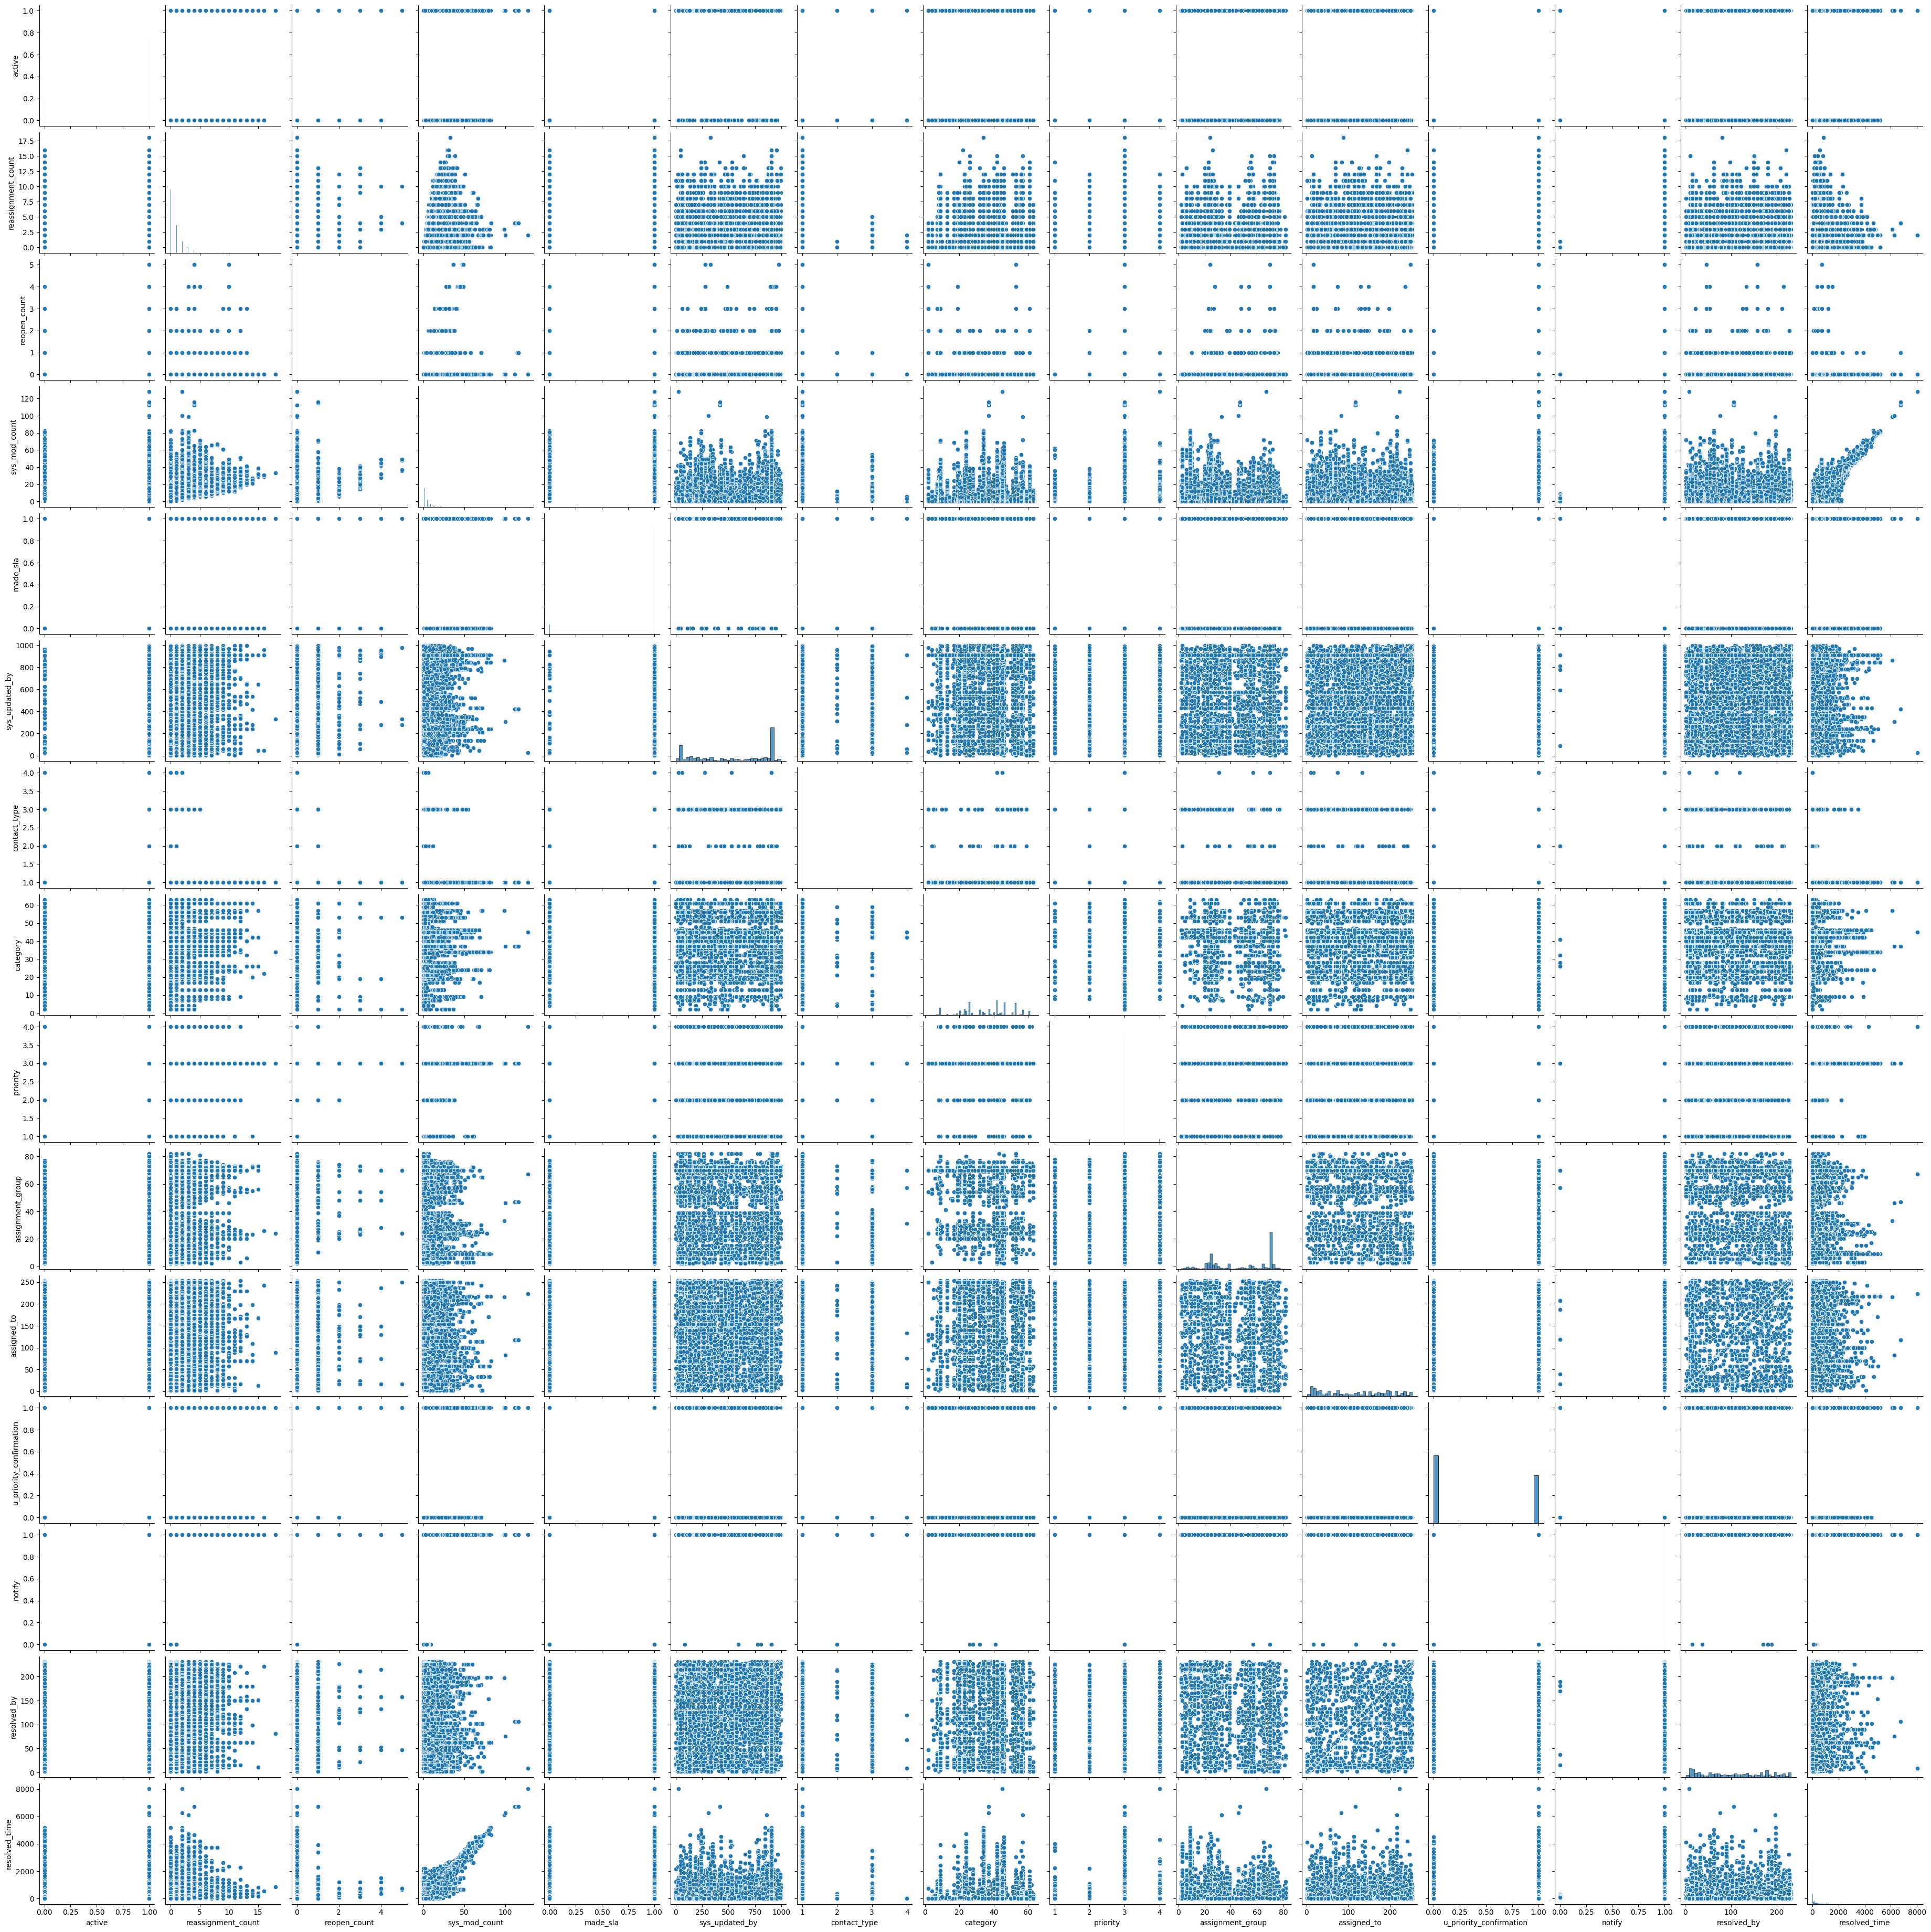

In [28]:
sns.pairplot(df_final,)

In [ ]:
# mean = df_final["resolved_time"].mean()
# std = df_final["resolved_time"].std()

# df_no_outliers = df_final[(df_final["resolved_time"] >= mean - 3*std) & (df_final["resolved_time"] <= mean + 3*std)]
# df_no_outliers
#sns.pairplot(df_no_outliers)

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,category,priority,assignment_group,assigned_to,u_priority_confirmation,notify,resolved_by,resolved_time
4,1,0,0,0,1,746,1,40,3,70,89,0,1,81,29.200000
5,1,1,0,1,1,21,1,40,3,24,31,0,1,81,29.200000
6,1,1,0,2,1,21,1,40,3,24,31,0,1,81,29.200000
7,1,1,0,3,1,804,1,40,3,24,31,0,1,81,29.200000
8,1,1,0,4,1,703,1,40,3,24,31,0,1,81,29.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,1,1,0,3,1,27,2,42,3,31,10,1,1,9,0.733333
141707,0,1,0,4,1,27,2,42,3,31,10,1,1,9,0.733333
141708,1,0,0,0,1,908,2,42,3,70,10,0,1,9,2.350000
141710,1,1,0,2,1,27,2,42,3,31,10,1,1,9,2.350000


In [30]:
df_final['reopen_count'].describe()

count    87335.000000
mean         0.015744
std          0.150698
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: reopen_count, dtype: float64

In [31]:
df_final.corr()

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,category,priority,assignment_group,assigned_to,u_priority_confirmation,notify,resolved_by,resolved_time
active,1.000000,-0.005818,0.017666,-0.194413,0.546241,-0.569453,-0.010141,-0.022460,-0.024497,-0.085876,0.055076,-0.493025,0.015166,0.047796,0.026919
reassignment_count,-0.005818,1.000000,0.114199,0.561522,-0.154214,0.047102,-0.008991,0.018600,-0.022983,-0.124166,0.095062,0.017773,-0.001454,0.086973,0.235300
reopen_count,0.017666,0.114199,1.000000,0.195053,-0.015213,0.004352,-0.002709,0.007419,0.006277,0.014303,0.004886,0.088678,0.002762,0.000927,0.059299
sys_mod_count,-0.194413,0.561522,0.195053,1.000000,-0.356303,0.162532,0.004719,0.014675,-0.038337,-0.166642,0.084571,0.264605,-0.003000,0.075626,0.733679
made_sla,0.546241,-0.154214,-0.015213,-0.356303,1.000000,-0.311024,-0.011842,-0.032091,0.065237,0.052929,-0.043646,-0.198001,0.034355,-0.046481,-0.197952
sys_updated_by,-0.569453,0.047102,0.004352,0.162532,-0.311024,1.000000,0.015345,0.019427,0.002856,-0.006546,0.255963,0.257237,-0.021589,0.254144,-0.002235
contact_type,-0.010141,-0.008991,-0.002709,0.004719,-0.011842,0.015345,1.000000,0.020172,-0.008845,0.001511,-0.001809,0.026675,-0.162585,0.000055,0.009503
category,-0.022460,0.018600,0.007419,0.014675,-0.032091,0.019427,0.020172,1.000000,-0.052202,0.115578,0.061323,0.032822,0.016602,0.053892,0.016925
priority,-0.024497,-0.022983,0.006277,-0.038337,0.065237,0.002856,-0.008845,-0.052202,1.000000,0.017895,-0.032008,-0.028214,-0.002265,-0.032056,-0.005041
assignment_group,-0.085876,-0.124166,0.014303,-0.166642,0.052929,-0.006546,0.001511,0.115578,0.017895,1.000000,-0.280188,0.171919,-0.026863,-0.270427,-0.184485


In [32]:
df_final=df_final.drop(columns=['active','reopen_count','made_sla','contact_type','priority','u_priority_confirmation','notify','resolved_by'], errors='ignore')

In [33]:
train = df_final.sample(frac=0.8, random_state=100)
X = train # podría dejar reassignment_count, sys_mod_count, sys_updated_by, resolved_by, category, assignment_group, assigned_to
y = train["resolved_time"]
test = df_final.drop(train.index)
test

,reassignment_count,sys_mod_count,sys_updated_by,category,assignment_group,assigned_to,resolved_time
5,1,1,21,40,24,31,29.200000
19,0,6,908,20,70,6,20.750000
20,0,0,340,9,25,125,53.466667
41,0,1,265,53,70,78,80.833333
44,1,4,307,53,28,78,80.833333
...,...,...,...,...,...,...,...
141658,1,2,27,42,31,10,0.116667
141665,0,1,265,42,70,73,0.066667
141666,0,2,908,42,70,73,0.066667
141676,1,2,27,45,31,10,23.066667


In [34]:
train

,reassignment_count,sys_mod_count,sys_updated_by,category,assignment_group,assigned_to,resolved_time
27442,3,10,135,26,25,57,452.333333
73833,0,1,44,42,70,13,0.133333
81246,3,3,336,34,27,44,22.983333
87831,2,5,171,51,54,49,237.450000
52604,2,3,643,57,28,78,26.083333
...,...,...,...,...,...,...,...
78904,1,2,360,53,68,97,1.933333
61284,1,1,804,51,70,17,140.866667
29490,0,0,340,51,64,94,0.050000
46049,0,2,859,23,20,224,5.083333


In [35]:
train_X = train.copy()
test_X = test.copy()

In [36]:
train_y = train_X.pop('resolved_time')
test_y = test_X.pop('resolved_time')
test_y

5         29.200000
19        20.750000
20        53.466667
41        80.833333
44        80.833333
            ...    
141658     0.116667
141665     0.066667
141666     0.066667
141676    23.066667
141678    23.066667
Name: resolved_time, Length: 17467, dtype: float64

In [37]:
y_scaler = StandardScaler()

# Ajustar y transformar la variable objetivo de entrenamiento
train_y_scaled = y_scaler.fit_transform(train_y.values.reshape(-1, 1))

# Transformar la de prueba
test_y_scaled = y_scaler.transform(test_y.values.reshape(-1, 1))

In [38]:
features_arr = np.array(train_X)
features_norm = tf.keras.layers.Normalization(input_shape=(6,))

c:\Users\Usuario\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
features_norm.adapt(features_arr)

Arquitectura de la red

In [41]:
base_model = keras.Sequential([features_norm,
layers.Dense(2, activation='sigmoid'),
layers.Dense(2, activation='sigmoid'),
layers.Dense(1, activation='sigmoid'),
layers.Dense(1, activation='sigmoid'),
layers.Dense(1, activation='sigmoid'),
layers.Dense(1, activation='sigmoid'),
layers.Dense(1)])
# o quito varaibles o quito neuronas

#esto da sobre ajuste 
# base_model = keras.Sequential([
# features_norm,
# layers.Dense(16, activation='relu'),
# layers.Dense(8, activation='relu'),
# layers.Dense(1)
# ])

In [42]:
base_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
loss='mse')

In [43]:
base_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 6)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44 (180.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 13 (56.00 B)

In [44]:
history_base = base_model.fit(
train_X, train_y_scaled,
validation_split=0.2,
epochs=40)

Epoch 1/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0110 - val_loss: 0.9564
Epoch 2/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.0109 - val_loss: 0.9558
Epoch 3/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.0011 - val_loss: 0.9220
Epoch 4/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9141 - val_loss: 0.8052
Epoch 5/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8090 - val_loss: 0.7223
Epoch 6/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.7397 - val_loss: 0.6749
Epoch 7/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6947 - val_loss: 0.6423
Epoch 8/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6573 - val_loss: 0.6152
Epoch 9/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6268 - val_loss: 0.5927
Epoch 10/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6023 - val_loss: 0.5703
Epoch 11/40
1747/1747 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5820 - val_loss: 0.5545
Epoch 12/40
1747/1747 ━━━━━━━━

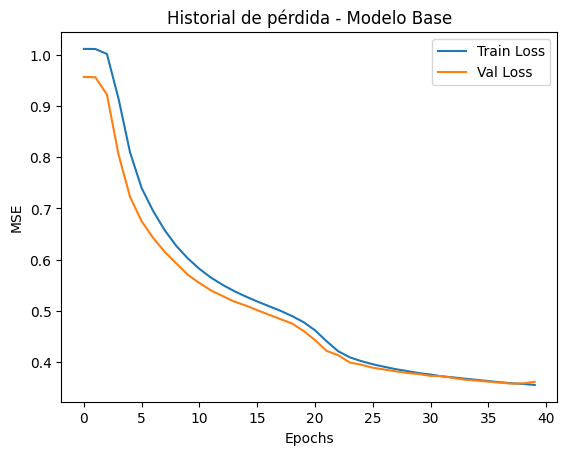

In [45]:
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.title('Historial de pérdida - Modelo Base')
plt.show()

In [46]:
y_pred_scaled = base_model.predict(test_X)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
test_X

,reassignment_count,sys_mod_count,sys_updated_by,category,assignment_group,assigned_to
5,1,1,21,40,24,31
19,0,6,908,20,70,6
20,0,0,340,9,25,125
41,0,1,265,53,70,78
44,1,4,307,53,28,78
...,...,...,...,...,...,...
141658,1,2,27,42,31,10
141665,0,1,265,42,70,73
141666,0,2,908,42,70,73
141676,1,2,27,45,31,10


In [70]:
a=y_pred.flatten()
a

array([ 87.85749 ,  76.444214,  76.79084 , ...,  75.77993 ,  95.6058  ,
       133.9518  ], shape=(17467,), dtype=float32)

In [53]:
df_pred = pd.DataFrame(y_pred, columns=["resolved_time_pred"])

print(df_pred.describe())

       resolved_time_pred
count        17467.000000
mean           154.987686
std            233.011917
min             75.609283
25%             76.880215
50%             83.592667
75%            139.343689
max           2403.493652


In [69]:
test_y.values

array([29.2       , 20.75      , 53.46666667, ...,  0.06666667,
       23.06666667, 23.06666667], shape=(17467,))

In [77]:
train_X['sys_mod_count'].describe()

count    69868.000000
mean         4.398208
std          5.980001
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        128.000000
Name: sys_mod_count, dtype: float64

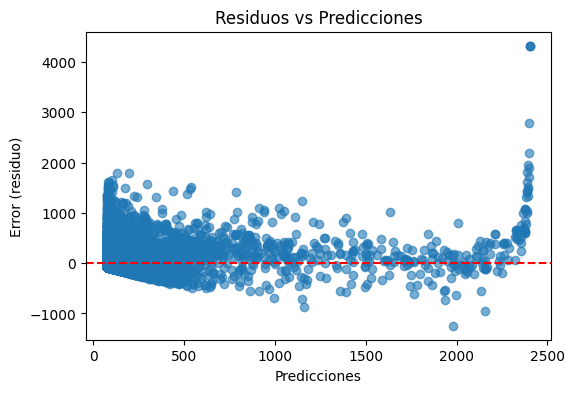

In [71]:
residuos = test_y.values - y_pred.flatten()

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Error (residuo)")
plt.title("Residuos vs Predicciones")
plt.show()

546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step


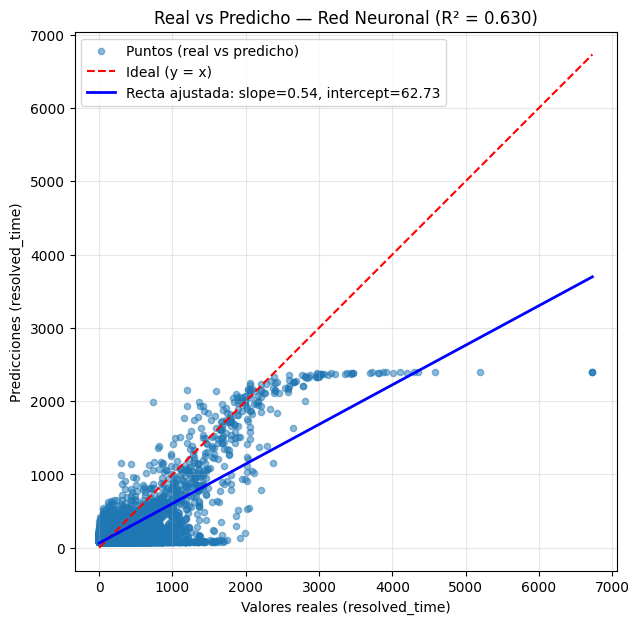

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1) Predicciones y escalado inverso (ya hecho por ti)
y_pred_scaled = base_model.predict(test_X)         # shape (n,1)
y_pred = y_scaler.inverse_transform(y_pred_scaled) # shape (n,1)

# 2) Aplanar para tener vectores 1D
y_pred_flat = np.asarray(y_pred).ravel()           # shape (n,)
y_true = np.asarray(test_y).ravel()                # shape (n,)

# 3) Rango común para la línea ideal y=x
min_val = min(y_true.min(), y_pred_flat.min())
max_val = max(y_true.max(), y_pred_flat.max())

# 4) Recta ajustada (predicho vs real)
reg = LinearRegression()
reg.fit(y_true.reshape(-1, 1), y_pred_flat)        # ajusta y_pred ~ y_true
y_line = np.linspace(min_val, max_val, 200)
y_fit_line = reg.predict(y_line.reshape(-1, 1))

# 5) Métrica R^2
r2 = r2_score(y_true, y_pred_flat)

# 6) Plot
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred_flat, alpha=0.5, s=20, label="Puntos (real vs predicho)")
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label="Ideal (y = x)")
plt.plot(y_line, y_fit_line, 'b-', linewidth=2,
         label=f"Recta ajustada: slope={reg.coef_[0]:.2f}, intercept={reg.intercept_:.2f}")
plt.xlabel("Valores reales (resolved_time)")
plt.ylabel("Predicciones (resolved_time)")
plt.title(f"Real vs Predicho — Red Neuronal (R² = {r2:.3f})")
plt.legend()
plt.axis('equal')        # opcional: hace escala 1:1 en ambos ejes
plt.grid(alpha=0.3)
plt.show()

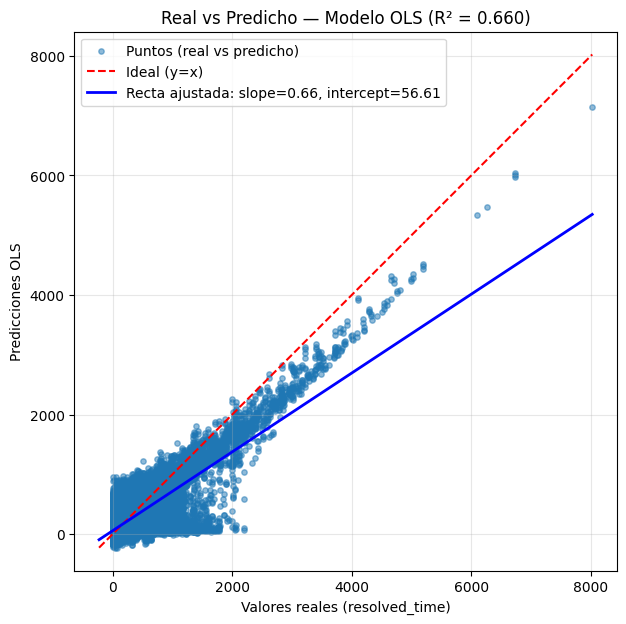

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# Valores reales y predichos del modelo OLS
y_true = np.asarray(y_out).ravel()
y_pred = np.asarray(model.fittedvalues).ravel()

# Calcular R²
r2 = r2_score(y_true, y_pred)

# Rango común para dibujar la línea ideal
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

# Recta ajustada (pred vs real)
reg = LinearRegression()
reg.fit(y_true.reshape(-1, 1), y_pred)
y_line = np.linspace(min_val, max_val, 200)
y_fit_line = reg.predict(y_line.reshape(-1, 1))

# Gráfico
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.5, s=15, label="Puntos (real vs predicho)")
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label="Ideal (y=x)")
plt.plot(y_line, y_fit_line, 'b-', linewidth=2,
         label=f"Recta ajustada: slope={reg.coef_[0]:.2f}, intercept={reg.intercept_:.2f}")

plt.xlabel("Valores reales (resolved_time)")
plt.ylabel("Predicciones OLS")
plt.title(f"Real vs Predicho — Modelo OLS (R² = {r2:.3f})")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

In [85]:
y_out

,resolved_time
4,29.200000
5,29.200000
6,29.200000
7,29.200000
8,29.200000
...,...
141706,0.733333
141707,0.733333
141708,2.350000
141710,2.350000


In [ ]:
x_out

,active,reassignment_count,reopen_count,sys_mod_count,made_sla,sys_updated_by,contact_type,category,priority,assignment_group,assigned_to,u_priority_confirmation,notify,resolved_by
4,1,0,0,0,1,746,1,40,3,70,89,0,1,81
5,1,1,0,1,1,21,1,40,3,24,31,0,1,81
6,1,1,0,2,1,21,1,40,3,24,31,0,1,81
7,1,1,0,3,1,804,1,40,3,24,31,0,1,81
8,1,1,0,4,1,703,1,40,3,24,31,0,1,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141706,1,1,0,3,1,27,2,42,3,31,10,1,1,9
141707,0,1,0,4,1,27,2,42,3,31,10,1,1,9
141708,1,0,0,0,1,908,2,42,3,70,10,0,1,9
141710,1,1,0,2,1,27,2,42,3,31,10,1,1,9
